# 📈 Machine Learning — PP2: Regressão Baseada em Resíduos
> **Projeto Brasil em Foco | PISI 3 — UFRPE 2026.1**


- 👥 **Autores:** Arthur Barbosa, Danielly Nunes, Gabriel Sabino, Isadora Morais, Luiz Vinícius
- 🔗 **Repositório:** [github.com/IsadoraMoraiss/Project_Pisi3](https://github.com/IsadoraMoraiss/Project_Pisi3.git)
- 🗂️ **Dataset:** [Brazilian Cities — Kaggle](https://www.kaggle.com/datasets/crisparada/brazilian-cities)
- 📚 **Metodologia:** KDD (Knowledge Discovery in Databases)


## 🎯 Pergunta de Negócio

> *"Dado o perfil socioeconômico de um município (PIB, população, densidade e região),  
> qual seria o seu nível esperado de absorção turística (leitos por mil habitantes)?  
> E onde o real fica muito abaixo do esperado?"*

Municípios com **resíduo muito negativo** (modelo previu muito mais do que a realidade)  
são as **Joias Ocultas** — alto potencial socioeconômico, baixo aproveitamento turístico.



## 🗺️ Fluxo KDD

| Fase KDD | Seção |
|---|---|
| Seleção & Pré-processamento | 1–3 |
| Transformação (Pipeline) | 3 |
| Mineração (Treinamento + GridSearch) | 4 |
| Avaliação (R², MAE, RMSE + Overfitting) | 5 |
| Conhecimento (Resíduos + Joias Ocultas) | 6 |
| Exportação do Campeão | 7 |


---
## ⚙️ Seção 1 — Configuração do Ambiente e Definição da SEED

`SEED = 42` é fixada em **todos** os pontos de aleatoriedade para garantir
**reprodutibilidade estrita**: os resultados serão idênticos a cada execução.


In [ ]:
# ── Bibliotecas gerais ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import joblib
import os

# ── Scikit-Learn: Pré-processamento ──────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ── Scikit-Learn: Modelos de Regressão ────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# ── Scikit-Learn: Validação e Métricas ───────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    KFold,                   # KFold tradicional — target contínuo não precisa de estratificação
    RepeatedKFold,           # alternativa mais robusta
    cross_validate,
    GridSearchCV,
)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    make_scorer,
)

# ── Configurações globais ─────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
np.random.seed(42)

# ── SEED ÚNICA E DOCUMENTADA ──────────────────────────────────────────────────
# Utilizada em: train_test_split, KFold, RandomForestRegressor,
#               GradientBoostingRegressor, GridSearchCV.
SEED = 42

print(f'✅ Ambiente configurado | SEED = {SEED}')
import sklearn
print(f'   pandas  {pd.__version__} | numpy {np.__version__} | sklearn {sklearn.__version__}')

✅ Ambiente configurado | SEED = 42
   pandas  2.2.2 | numpy 2.0.2 | sklearn 1.6.1


---
## 📥 Seção 2 — Carregamento dos Dados (KDD — Seleção)

### Anti-circularidade e Anti-colinearidade

```
Features (X)                        Target (y)
─────────────────────────────────   ─────────────────────────────────────
PIB_per_capita  (IBGE/RAIS)         Leitos_por_Mil_Hab  (IBGE/RAIS/CADASTUR)
Populacao       (IBGE)              → Proxy de absorção turística estrutural
Densidade       (IBGE)              → Calculado como BEDS / IBGE_RES_POP × 1.000
Regiao          (IBGE)
─────────────────────────────────
❌ IDHM removido — alta correlação com PIB (multicolinearidade)
```

O dataset aceita **dois modos**:
- **Modo Real**: carrega o CSV do disco / Google Drive.
- **Modo Mock**: gera 300 municípios simulados automaticamente (fallback).


In [ ]:
# ── Tentar carregar o dataset real ────────────────────────────────────────────
# No Google Colab:
# from google.colab import drive; drive.mount('/content/drive')
# CSV_PATH = '/content/drive/MyDrive/BRAZIL_CITIES.csv'

CSV_PATH = 'BRAZIL_CITIES.csv'
MODO_REAL = False

if os.path.exists(CSV_PATH):
    df_raw = pd.read_csv(CSV_PATH, sep=';', encoding='latin-1', decimal=',')

    # Padronizar colunas (mesmo padrão da EDA e Clusterização)
    df_raw.columns = (
        df_raw.columns
        .str.lower().str.strip()
        .str.replace(' ', '_', regex=False)
        .str.replace(r'[^a-z0-9_]', '', regex=True)
    )

    # Mapeamento UF → Macrorregião
    map_regiao = {
        'AC':'Norte','AM':'Norte','AP':'Norte','PA':'Norte',
        'RO':'Norte','RR':'Norte','TO':'Norte',
        'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste',
        'PB':'Nordeste','PE':'Nordeste','PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
        'DF':'Centro-Oeste','GO':'Centro-Oeste','MS':'Centro-Oeste','MT':'Centro-Oeste',
        'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
        'PR':'Sul','RS':'Sul','SC':'Sul',
    }

    # Converter e selecionar colunas
    for col in ['gdp_capita', 'ibge_res_pop', 'beds', 'estimated_pop', 'area']:
        if col in df_raw.columns:
            df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

    # Calcular target: Leitos por 1.000 habitantes
    if 'beds' in df_raw.columns and 'ibge_res_pop' in df_raw.columns:
        df_raw['Leitos_por_Mil_Hab'] = (
            df_raw['beds'] / (df_raw['ibge_res_pop'] + 1) * 1000
        )

    # Calcular densidade se não existir
    if 'area' in df_raw.columns and 'ibge_res_pop' in df_raw.columns:
        df_raw['Densidade'] = df_raw['ibge_res_pop'] / (df_raw['area'] + 1)
    else:
        df_raw['Densidade'] = np.nan

    df_raw['Regiao'] = df_raw['state'].map(map_regiao)

    # Renomear para nomenclatura padronizada do projeto
    df_raw = df_raw.rename(columns={
        'gdp_capita':    'PIB_per_capita',
        'ibge_res_pop':  'Populacao',
    })

    df_raw = df_raw[['PIB_per_capita','Populacao','Densidade',
                      'Regiao','Leitos_por_Mil_Hab']].dropna(
        subset=['PIB_per_capita','Populacao','Leitos_por_Mil_Hab']
    )

    MODO_REAL = True
    print(f'✅ Dataset REAL carregado: {df_raw.shape[0]} municípios')
    print(f'   Target — Leitos_por_Mil_Hab:  média={df_raw["Leitos_por_Mil_Hab"].mean():.2f}'
          f'  mediana={df_raw["Leitos_por_Mil_Hab"].median():.2f}'
          f'  max={df_raw["Leitos_por_Mil_Hab"].max():.2f}')
else:
    print('⚠️  CSV não encontrado — ativando MODO MOCK (dados simulados).')
    MODO_REAL = False

✅ Dataset REAL carregado: 887 municípios
   Target — Leitos_por_Mil_Hab:  média=6.98  mediana=2.43  max=710.53


### 2.1 Mock Data — Simulação Realista

**Target simulado (`Leitos_por_Mil_Hab`)**: log-normal assimétrica,
espelhando a concentração real do turismo brasileiro (maioria das cidades
tem muito poucos leitos; poucos destinos consolidados têm muitos).

**Correlação sintética introduzida**: cidades com maior PIB tendem a
ter mais leitos, mas com muito ruído — simulando o padrão real de
que estrutura econômica explica *parte* do turismo, não tudo.


In [ ]:
if not MODO_REAL:
    np.random.seed(SEED)
    N = 300

    regioes  = ['Norte','Nordeste','Centro-Oeste','Sudeste','Sul']
    pesos_r  = [0.15, 0.28, 0.12, 0.30, 0.15]

    # Features socioeconômicas
    pib      = np.random.lognormal(mean=10.0, sigma=0.75, size=N).clip(4_000, 90_000)
    pop      = np.random.lognormal(mean=10.5, sigma=1.40, size=N).clip(3_000, 3_000_000)
    dens     = np.random.exponential(scale=85, size=N).clip(1, 2500)
    regiao   = np.random.choice(regioes, size=N, p=pesos_r)

    # Target: log-normal com correlação sintética com PIB
    # Leitos_por_Mil = f(PIB) + ruído — o modelo aprenderá essa relação
    sinal    = 0.3 * (np.log(pib) - np.log(pib).mean())
    leitos   = np.exp(sinal + np.random.normal(loc=0.5, scale=0.9, size=N)).clip(0.01, 80)

    # Municípios da região Sul e Sudeste tendem a ter mais leitos (Gramado, Búzios etc.)
    mask_sul = np.isin(regiao, ['Sul', 'Sudeste'])
    leitos[mask_sul] *= np.random.uniform(1.1, 1.4, mask_sul.sum())

    df_raw = pd.DataFrame({
        'PIB_per_capita':     pib,
        'Populacao':          pop,
        'Densidade':          dens,
        'Regiao':             regiao,
        'Leitos_por_Mil_Hab': leitos,
    })

    # Nome fictício dos municípios (para a seção de Joias Ocultas)
    df_raw.insert(0, 'Municipio', [f'Município_{i+1:03d}' for i in range(N)])

    print(f'✅ MODO MOCK ativado | {N} municípios simulados')
    print(f'\n   Estatísticas do target (Leitos por Mil Hab):')
    print(df_raw['Leitos_por_Mil_Hab'].describe().round(3).to_string())

print(f'\n📐 Shape: {df_raw.shape}')
df_raw.head(3)


📐 Shape: (887, 5)


,PIB_per_capita,Populacao,Densidade,Regiao,Leitos_por_Mil_Hab
2,15628.4,15757.0,NaN,Centro-Oeste,2.157634
6,6982.7,8316.0,15.409131,Nordeste,2.885656
16,18088.4,104047.0,NaN,Nordeste,0.538213


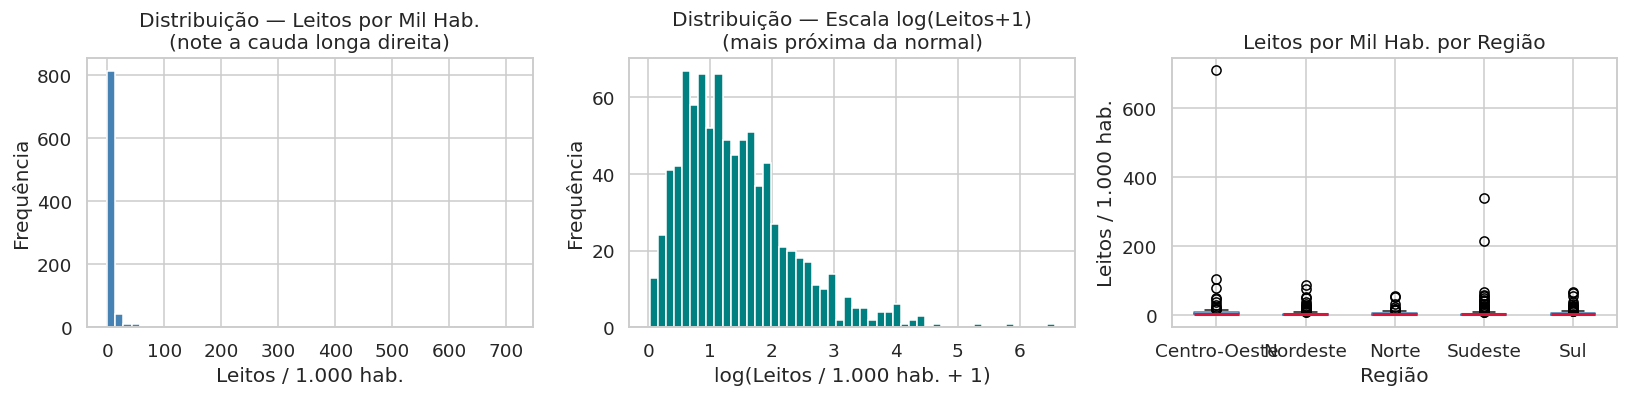

Nota: a assimetria à direita justifica avaliar log-transformação do target.
Fonte: elaborado pelos autores (2026).


In [ ]:
# ── Análise exploratória rápida do target ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma do target
axes[0].hist(df_raw['Leitos_por_Mil_Hab'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição — Leitos por Mil Hab.\n(note a cauda longa direita)')
axes[0].set_xlabel('Leitos / 1.000 hab.')
axes[0].set_ylabel('Frequência')

# Histograma na escala log
axes[1].hist(np.log1p(df_raw['Leitos_por_Mil_Hab']), bins=50, color='teal', edgecolor='white')
axes[1].set_title('Distribuição — Escala log(Leitos+1)\n(mais próxima da normal)')
axes[1].set_xlabel('log(Leitos / 1.000 hab. + 1)')
axes[1].set_ylabel('Frequência')

# Boxplot por região
df_raw.boxplot(column='Leitos_por_Mil_Hab', by='Regiao', ax=axes[2],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='crimson', linewidth=2))
axes[2].set_title('Leitos por Mil Hab. por Região')
axes[2].set_xlabel('Região'); axes[2].set_ylabel('Leitos / 1.000 hab.')
plt.suptitle('')

plt.tight_layout()
plt.savefig('fig_target_distribution.png', dpi=110, bbox_inches='tight')
plt.show()
print('Nota: a assimetria à direita justifica avaliar log-transformação do target.')
print('Fonte: elaborado pelos autores (2026).')
